# URSA MAJOR I

Ursa MajorI (UMaI) is a MW UFD satellite discovered by [Willman et al. 2005](https://iopscience.iop.org/article/10.1086/431760) as an overdensity of red, resolved stars in the SDSS data. 
It is located at a heliocentric distance of $\approx 100$ kpc with an old, metal-poor population. It has an absolute magnitude of $M_V \approx -5.1$ mag and a half-light radius of $\approx 250$ pc, placing it in the size range of classical dwarf spheroidals. 
[Garofalo et al. 2013](https://iopscience.iop.org/article/10.1088/0004-637X/767/1/62) identified seven RRLs via optical time-series photometry. 
Isodensity maps of its RGB and HB stars reveal an S-shaped morphology, indicating tidal disruption by the MW gravitational field ([Okamoto et al. 2008](https://doi.org/10.1051/0004-6361:20078232)).

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import warnings
warnings.filterwarnings('ignore')

## Joint Proper Motions Histograms

In [2]:
def scatter_hist(x, y, x_rr, y_rr, ax, ax_histx, ax_histy, center_pm, err_pm):
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    ax.set_xlim(-20,20)
    ax.set_ylim(-20,20)
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
    ax.set_ylabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
    
    ax.scatter(x, y, marker='o', s=10, label=r'Sources in 6$r_h$', color='lightgrey')
    ax.scatter(x_rr, y_rr, marker='o', edgecolor='k', s=100, label=r'RR Lyrae Variables', color='gold', zorder=2)

    ax_histx.set_ylim(0,1)
    ax_histy.set_xlim(0,1)
    ax_histx.tick_params(labelsize=14)
    ax_histy.tick_params(labelsize=14)
    ax_histx.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histy.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histx.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    ax_histy.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    
    ax_histx.hist(x, bins=len(x), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$')
    ax_histy.hist(y, bins=len(y), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$', orientation='horizontal')
    
    ax_histx.hist(x_rr, bins=len(x_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables')
    ax_histy.hist(y_rr, bins=len(y_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables', orientation='horizontal')
    
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='white', linewidth=5)
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='white', linewidth=5)
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='deepskyblue', linewidth=2, label=r'$\mu_{pmra}$=' + '{:.3f}'.format(center_pm[0]) + '\n' + r'$\sigma_{pmra}$=' + '{:.3f}'.format(err_pm[0]))
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='deepskyblue', linewidth=2, label=r'$\mu_{pmdec}$=' + '{:.3f}'.format(center_pm[1]) + '\n' + r'$\sigma_{pmdec}$=' + '{:.3f}'.format(err_pm[1]))
    
    ax_histx.axvspan(center_pm[0] - 3*err_pm[0], center_pm[0] + 3*err_pm[0], alpha=0.1, color='cyan', zorder=1)
    ax_histy.axhspan(center_pm[1] - 3*err_pm[1], center_pm[1] + 3*err_pm[1], alpha=0.1, color='cyan', zorder=1)
    
    ax_histx.legend(loc=1, fontsize=14, framealpha=0.95)
    ax_histy.legend(loc=1, fontsize=14, framealpha=0.95)

## Wesenheit Relation for RR Lyrae ([Garofalo et al. 2022](https://doi.org/10.1093/mnras/stac735))

In [3]:
## Garofalo et al. 2022, pag. 14

def pw(period, fe, mu0) : # 'period' in log10
    pw_line = - 2.49 * period + 0.14 * fe - 0.88 + mu0

    return pw_line


## Garofalo et al. 2022, pag. 12-13

def wesen(g, bp, rp) :
    w = g - 1.922 * (bp - rp)
    
    return w


## Error Propagation

def wesen_err(g_err, bp_err, rp_err) :
    w_err = g_err + 1.922 * (bp_err + rp_err)
    
    return w_err

## Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
##### NOTE on errors: 
If using "int_g_average" for $G$-band magnitude, we already have "int_g_average_error"; if using "phot_g_mean_mag", we use the flux-derived error ("phot_g_err"). For $G_{BP}$ and $G_{RP}$, we exclusively use "phot_*_mean_mag" as they are more reliable.

In [4]:
def mag_err(flux, flux_err) :
    mag_error = 1.0857 * flux_err / flux
    
    return mag_error

## Data download

In [5]:
data = pd.read_csv('Data/UrsaMajorI_3.csv', header=0)
#cu5

data_rr = pd.read_csv('Data/vari_rrlyrae.csv', header=0, low_memory=False)
#cu7=coordination unit of variables

data_class = pd.read_csv('Data/vari_classifier_result.csv', header=0)

### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [6]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'UrsaMajorI']

print(vivas)

       galaxy        ra      dec   M_V  distance  fe_h   r_h  epsilon    PA  \
3  UrsaMajorI  158.7706  51.9479 -5.12      97.0  -2.1  8.13     0.59  67.0   

    r_t  N_RR  N_RR.1  N_(RR)  N_RR.2 Ref  Ref.1 Ref.2  
3  24.0   7.0       6       0       7   1   16.0    24  


### Known RR Lyrae  in [Tau et al. 2024](https://iopscience.iop.org/article/10.3847/1538-3881/ad1509) (table 2)

In [7]:
tau_table = pd.read_csv('Papers_tables/Tau_table2.csv', header=0)

tau = tau_table[tau_table['galaxy'] == 'UrsaMajorI']

tau_complete = tau

print('RR Lyrae in Tau et al. (2024): ' + str(len(tau_complete)))

#tau_complete.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_Tau_complete.csv', index=False)


# Conversion to integers

tau['source_id'] = tau['source_id'].astype(int)

# From Tau, we keep only the 'source_id' column and merge it with the Gaia Archive data

tau = tau[['source_id']]

#print(tau)


# Merging with vari_classifier

tau = tau.merge(data_class, on='source_id')


# Merging with vari_rrlyrae

tau_rr = tau.merge(data_rr)
print(tau_rr['source_id'])

print('Correspondence with Gaia Variable Classifier: ' + str(len(tau)))
print('Correspondence with Gaia RR Lyrae: ' + str(len(tau_rr)))

# Tau RR Lyrae + those that do not match the Gaia catalogue
# NOTE: These are all of Tau RR Lyrae excluding the one without a Gaia source_id, 
# so the sample includes both vari_rrlyrae and vari_classifier entries

#tau.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_Tau.csv', index=False)


RR Lyrae in Tau et al. (2024): 8
0    847519849205957760
1    847520295882556928
2    847700718868881792
3    847701990178947840
4    847706663103625984
5    847707728255299712
6    847779132087730816
7    849022228766244992
Name: source_id, dtype: int64
Correspondence with Gaia Variable Classifier: 8
Correspondence with Gaia RR Lyrae: 8


### Spectroscopic members ([Waller et al. 2022](https://doi.org/10.1093/mnras/stac3563), table 8)

Some RRL "source_ids" in Waller2022 do not have direct Gaia counterparts. However, cross-matching RA and Dec (using TOPCAT) revealed many more matches, so we used this new cross-matched catalogue because Waller used EDR3.

In [8]:
memb_table = pd.read_csv('Papers_tables/Waller8.csv', header=0)

memb_complete = memb_table[memb_table['UFD'] == 'UMaI']

print('Spectroscopic Members: ' + str(len(memb_complete)))


## Correspondence with Gaia (gaiadr3.gaia_source)

memb_table_cross = pd.read_csv('Papers_tables/Waller8_UMaI_crossmatch.csv', header=0)

memb = memb_table_cross[memb_table_cross['UFD'] == 'UMaI']

memb = memb[memb['source_id'] != '—']

memb = memb[memb['PSAT'] > 0.7]

memb['source_id'] = memb['source_id'].astype(int)



## Mask for Sources which are not 'NaN' in proper motions

mask_memb = ((np.isnan(memb['pmra']) == False) & (np.isnan(memb['pmdec']) == False))

memb = memb[mask_memb]

print('Correspondence with Gaia Sources: ' + str(len(memb)))


## Correspondence with Gaia RR Lyrae (vari_rrlyrae)

memb_rr = memb.merge(data_rr)#, on='source_id')

print('Correspondence with Gaia RR Lyrae: ' + str(len(memb_rr)))

#memb_rr.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_memb.csv', index=False)

print(memb_rr['source_id'])


Spectroscopic Members: 56
Correspondence with Gaia Sources: 46
Correspondence with Gaia RR Lyrae: 7
0    847520295882556928
1    847706663103625984
2    847707728255299712
3    849022228766244992
4    847519849205957760
5    847700718868881792
6    847701990178947840
Name: source_id, dtype: int64


### Geometrical parameters of UrsaMajorI from [Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0) (table 1)

In [9]:
center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))
r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 8.13 arcmin


## Mask for Sources with non-Nan pmra, pmdec, phot_g bp rp, int_g bp rp

mask_initial = ((np.isnan(data['pmra']) == False) & (np.isnan(data['pmdec']) == False) &
               (np.isnan(data['phot_g_mean_mag']) == False) & (np.isnan(data['phot_bp_mean_mag']) == False) &
               (np.isnan(data['phot_rp_mean_mag']) == False))

data = data[mask_initial]

print('Sources within 3° (non-Nan values): ' + str(len(data)))



## Mask for Sources within 5r_h

mask = ((data['ra'] - center[0])**2 + (data['dec'] - center[1])**2) < (5*r_half)**2

data_5rh = data[mask]

print('Sources within 5r_h: ' + str(len(data_5rh)))

Sources within 3° (non-Nan values): 66679
Sources within 5r_h: 2120


### RR Lyrae + Variable star classified ([Gaia DR3](https://doi.org/10.1051/0004-6361/202243940), [Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657))

In [10]:
rr = data_rr.merge(data)
rr_5rh = data_rr.merge(data_5rh)

print('RR Lyrae within 3°: ' + str(len(rr)))
print('RR Lyrae within 5r_h: ' + str(len(rr_5rh)))

#rr.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_3deg.csv', index=False)

RR Lyrae within 3°: 23
RR Lyrae within 5r_h: 8


In [11]:
class_rr = data_class.merge(data)
class_5rh = data_class.merge(data_5rh)

print('Gaia Classified Variables: ' + str(len(class_rr)))
print('Gaia Classified Variables in 5r_h: ' + str(len(class_5rh)))

add_class_rr = class_rr.merge(rr, how='left', indicator=True).query('_merge == "left_only"')

print(str(len(add_class_rr)) + ' additional variables classified by Gaia within 3°')

Gaia Classified Variables: 23
Gaia Classified Variables in 5r_h: 8
0 additional variables classified by Gaia within 3°


### Sagittarius Stream ([Muraveva et al. 2025](https://doi.org/10.1051/0004-6361/202555670), table A3)

In [12]:
datafile_sgr = pd.read_csv('Papers_tables/Muraveva2025_TableA3.csv', header=0)

data_sgr = datafile_sgr[datafile_sgr['source_id'].isin(rr['source_id'])]

print('Sagittarius Stream RR Lyrae Candidates: ' + str(len(data_sgr)))

Sagittarius Stream RR Lyrae Candidates: 0


### Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag

In [13]:
rr['phot_g_mean_mag_error'] = mag_err(rr['phot_g_mean_flux'], rr['phot_g_mean_flux_error'])
rr['phot_bp_mean_mag_error'] = mag_err(rr['phot_bp_mean_flux'], rr['phot_bp_mean_flux_error'])
rr['phot_rp_mean_mag_error'] = mag_err(rr['phot_rp_mean_flux'], rr['phot_rp_mean_flux_error'])

## Maps

### RA - Dec

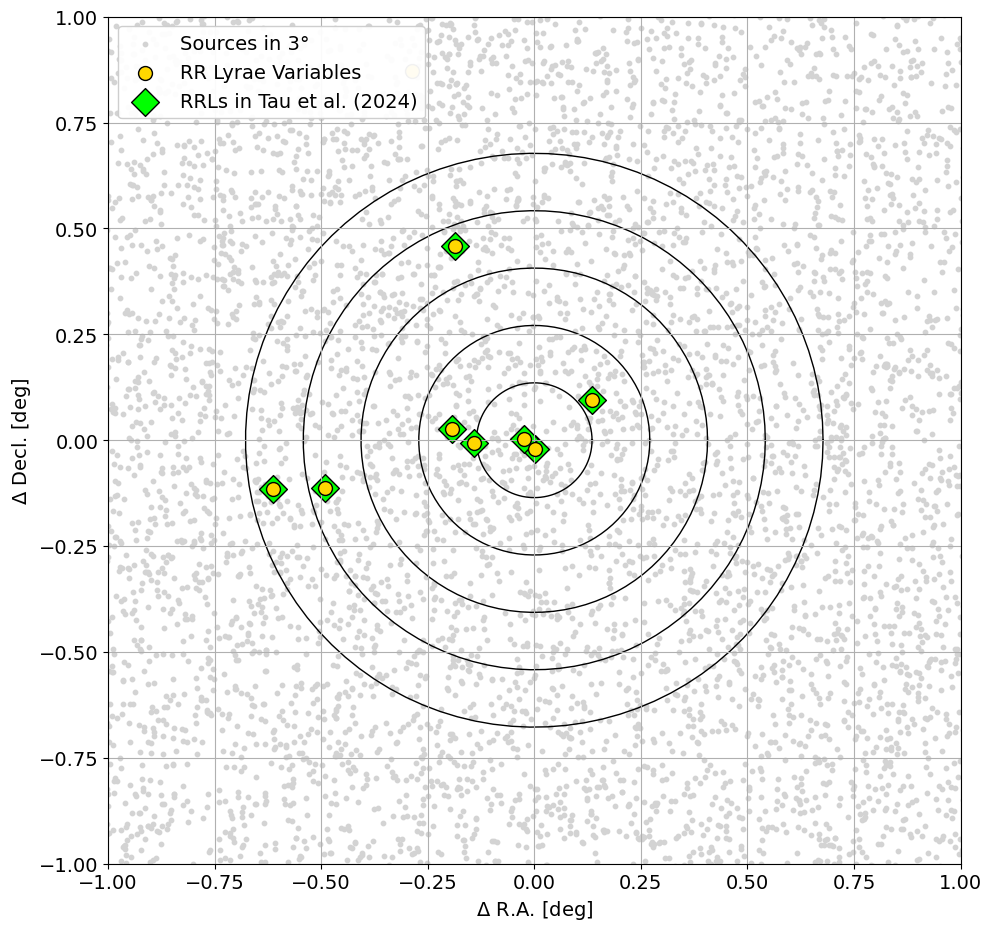

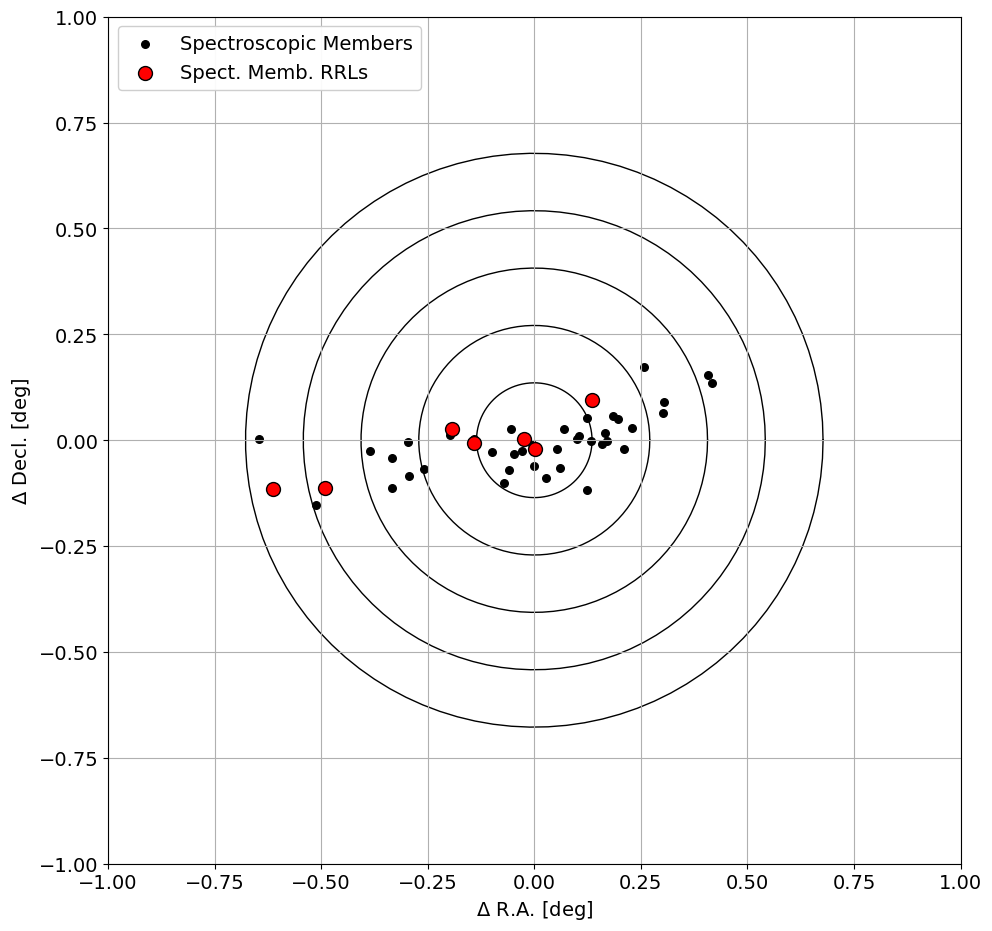

In [14]:
# Zoom in

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(11,11))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data['ra'] - center[0], data['dec'] - center[1], s=10, marker='o', c='lightgrey', label='Sources in 3°', zorder=0)
plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(tau['ra'] - center[0], tau['dec'] - center[1], s=200, marker='D', c='lime', edgecolor='k', label='RRLs in Tau et al. (2024)', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/UrsaMajorI/UrsaMajorI_initial_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


# Spectroscopic Members

plt.figure(figsize=(11,11))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=30, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/UrsaMajorI/UrsaMajorI_memb_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Colormap of RR Lyrae based on 'int_average_g'

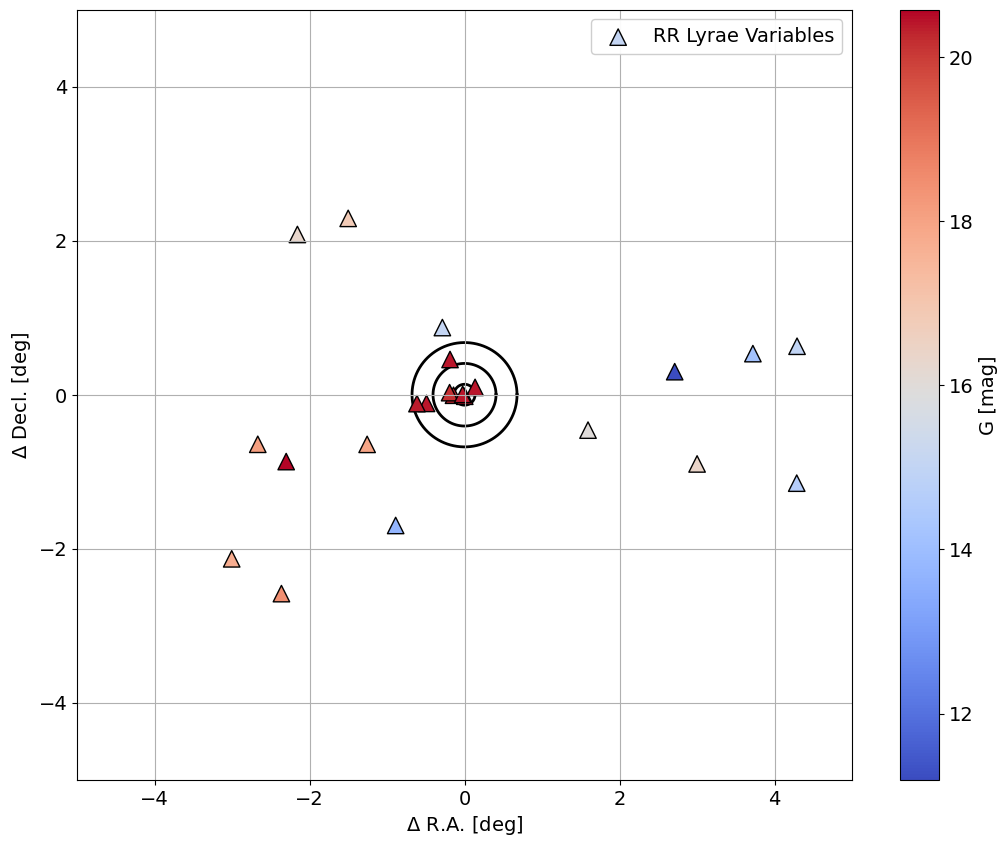

In [15]:
plt.figure(figsize=(12.5,10))
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], c=rr['int_average_g'], cmap='coolwarm', s=140, marker='^', edgecolor='k', label='RR Lyrae Variables', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=2, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('G [mag]', fontsize=14)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_colormap.png', bbox_inches='tight', pad_inches=0)
plt.show()

## RR Lyrae selection through Proper Motions + PWZ

### Proper Motions

#### Errors on Proper Motions ([Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657), table 3): comparison with Spectroscopic Members

This removal was not applied to Ursa Major I RRLs since they are expected be too faint, so affected by great uncertainties.

In [16]:
# Cut at pm_error = 0.5

print('Initial RR Lyrae: ', len(rr))

mask_pm05 = ((rr['pmra_error'] < 0.5) | (rr['pmdec_error'] < 0.5))
pm05 = rr[mask_pm05]

print('RR Lyrae with pmra_error and pmdec_error < 0.5: ', len(pm05))

if len(pm05) < len(rr) :
    print(str(len(rr) - len(pm05)) + ' RR Lyrae removed:')
    print(rr[~mask_pm05]['source_id'])
    
#rr[~mask_pm05].to_csv('Output/UrsaMajorI/UrsaMajorI_pmerr05.csv', index=False)

Initial RR Lyrae:  23
RR Lyrae with pmra_error and pmdec_error < 0.5:  16
7 RR Lyrae removed:
3     847552971994777216
5     847700718868881792
6     847706663103625984
10    847701990178947840
12    849022228766244992
16    847779132087730816
22    847520295882556928
Name: source_id, dtype: int64


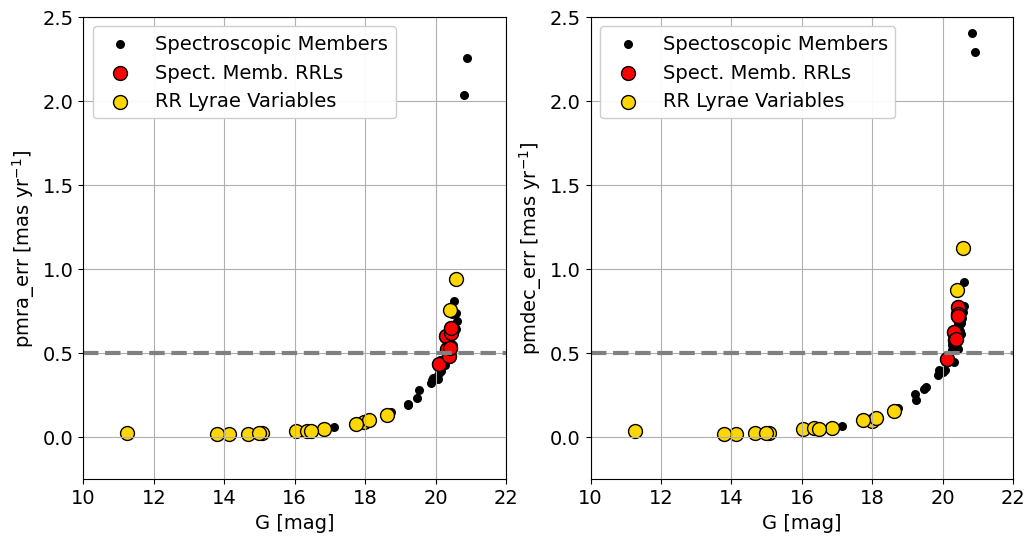

In [17]:
## PM ERRORS

pm1, (pmraerr1, pmdecerr1) = plt.subplots(1, 2, figsize=(12,6))

# PM RA with Spectroscopic Members

pmraerr1.set_xlim(10,22)
pmraerr1.set_ylim(-0.25,2.5)
pmraerr1.tick_params(labelsize=14)
pmraerr1.set_xlabel('G [mag]', fontsize=14)
pmraerr1.set_ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)
pmraerr1.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectroscopic Members')
pmraerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmra_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmraerr1.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmraerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmraerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmraerr1.grid(True)

## PM DEC with Spectroscopic Members

pmdecerr1.set_xlim(10,22)
pmdecerr1.set_ylim(-0.25,2.5)
pmdecerr1.tick_params(labelsize=14)
pmdecerr1.set_xlabel('G [mag]', fontsize=14)
pmdecerr1.set_ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)
pmdecerr1.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectoscopic Members')
pmdecerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmdec_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmdecerr1.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmdecerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmdecerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmdecerr1.grid(True)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_paper01.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

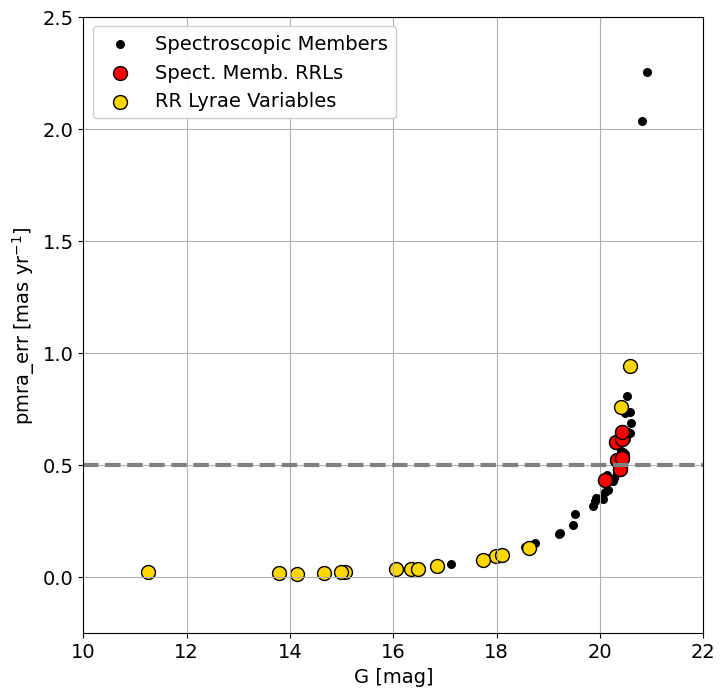

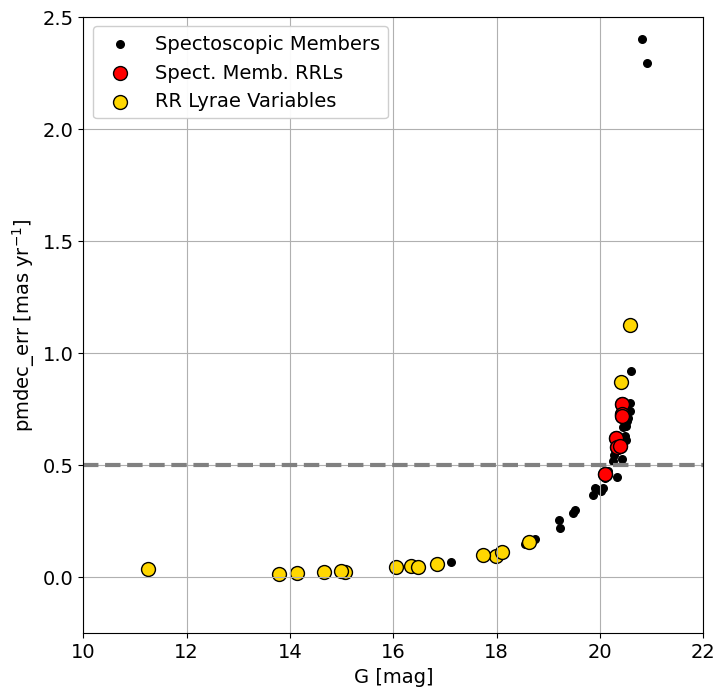

In [18]:
# PM RA with Spectroscopic Members


plt.figure(figsize=(8,8))
plt.xlim(10,22)
plt.ylim(-0.25,2.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('G [mag]', fontsize=14)
plt.ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)

plt.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectroscopic Members')
plt.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmra_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
plt.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
plt.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_paper01_1.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


## PM DEC with Spectroscopic Members


plt.figure(figsize=(8,8))
plt.xlim(10,22)
plt.ylim(-0.25,2.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('G [mag]', fontsize=14)
plt.ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)

plt.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectoscopic Members')
plt.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmdec_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
plt.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
plt.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_paper01_2.png', bbox_inches='tight', pad_inches=0.1)
plt.show()




#### Histograms

In [19]:
## Gaussian of Sources in 5*r_h

mask3 = ((data_5rh['pmra'] > -20) & (data_5rh['pmra'] < 20) & (data_5rh['pmdec'] > -20) & (data_5rh['pmdec'] < 20))
data_mask3 = data_5rh[mask3]

mu_ra, std_ra = norm.fit(data_mask3['pmra'])
mu_dec, std_dec = norm.fit(data_mask3['pmdec'])

x = np.linspace(-50, 50, 1000)
p_ra = norm.pdf(x, mu_ra, std_ra)
p_dec = norm.pdf(x, mu_dec, std_dec)


## Gaussian of RR Lyrae in 3°

mu_rr_ra, std_rr_ra = norm.fit(rr['pmra'])
mu_rr_dec, std_rr_dec = norm.fit(rr['pmdec'])

x_rr = np.linspace(-50, 50, 1000)
p_rr_ra = norm.pdf(x_rr, mu_rr_ra, std_rr_ra)
p_rr_dec = norm.pdf(x_rr, mu_rr_dec, std_rr_dec)



## Gaussian of Sectroscopic Members

memb_mask = memb

mu_memb_ra, std_memb_ra = norm.fit(memb_mask['pmra'])
mu_memb_dec, std_memb_dec = norm.fit(memb_mask['pmdec'])

x_memb = np.linspace(-20, 20, 1000)
p_memb_ra = norm.pdf(x_memb, mu_memb_ra, std_memb_ra)
p_memb_dec = norm.pdf(x_memb, mu_memb_dec, std_memb_dec)


## Proper Motion centers

center_mymemb = np.array(object=(mu_memb_ra, mu_memb_dec))
err_mymemb = np.array(object=(std_memb_ra, std_memb_dec))

In [20]:
array = {'name': ['sources_ra', 'sources_dec', 'rr_ra', 'rr_dec', 'memb_ra', 'memb_dec'],
         'mu': [mu_ra, mu_dec, mu_rr_ra, mu_rr_dec, mu_memb_ra, mu_memb_dec],
         'std': [std_ra, std_dec, std_rr_ra, std_rr_dec, std_memb_ra, std_memb_dec]}

array_mu_std = pd.DataFrame(array)

print(array_mu_std)

array_mu_std.to_csv('Output/UrsaMajorI/UrsaMajorI_mu_std.csv', index=False)

          name        mu       std
0   sources_ra -2.285191  6.554526
1  sources_dec -5.509938  5.621382
2        rr_ra -1.934834  4.639275
3       rr_dec -4.768008  8.713857
4      memb_ra -0.534353  0.623592
5     memb_dec -0.569140  0.750978


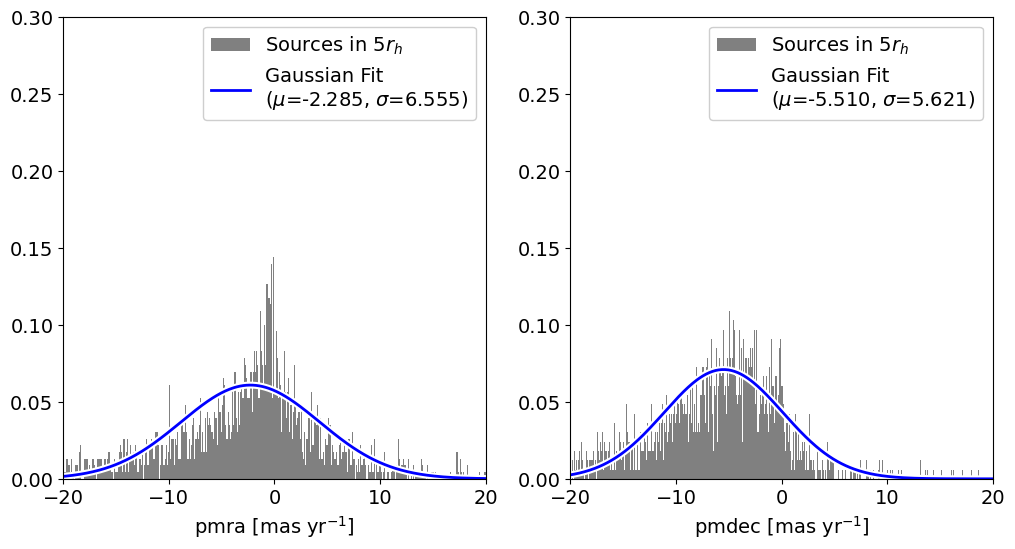

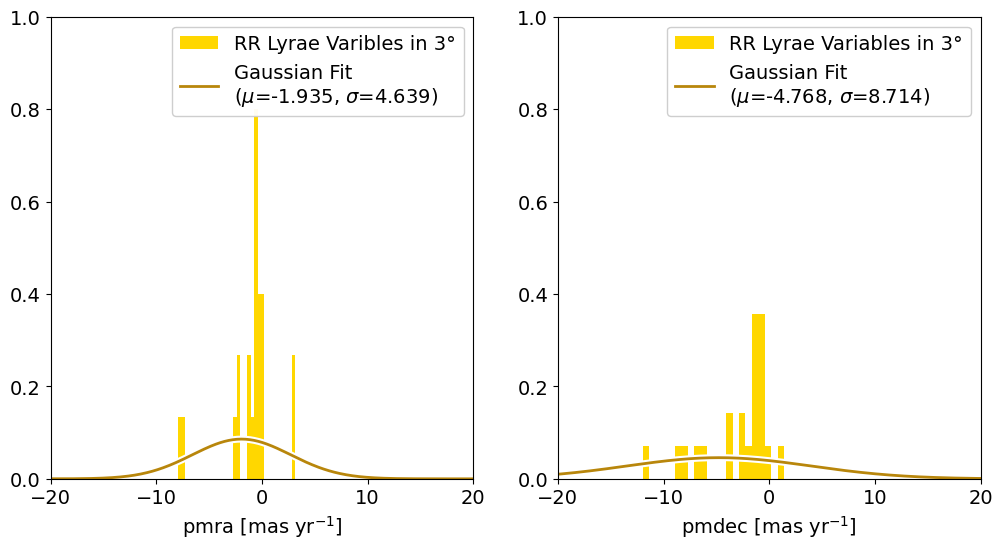

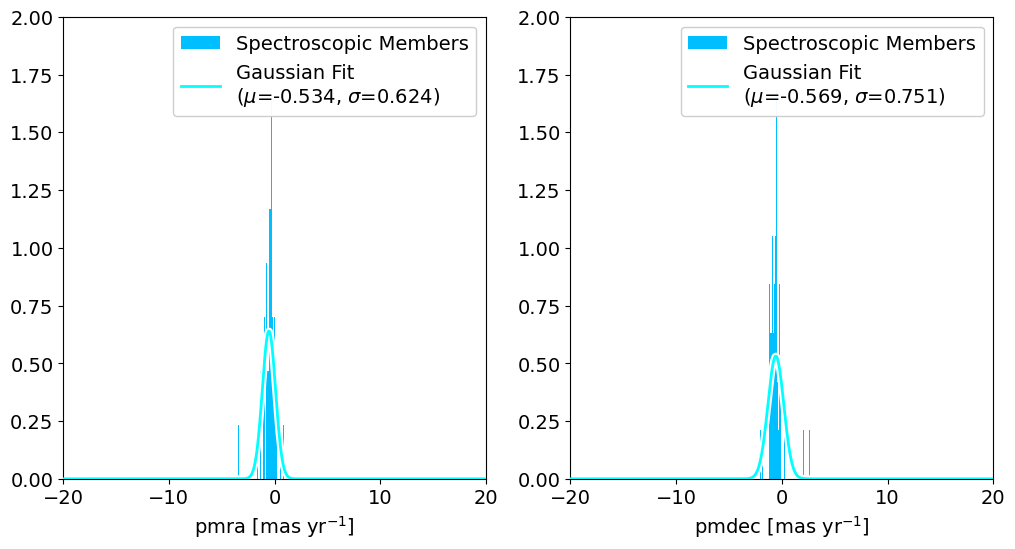

In [21]:
## Histograms

# Sources in 5*r_h

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.3)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(data_5rh['pmra'], bins=len(data_5rh), density=True, label=r'Sources in 5$r_h$', color='grey')
pmra1.plot(x, p_ra, c='white', linewidth=5)
pmra1.plot(x, p_ra, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_ra) + ', $\sigma$=' + '{:.3f}'.format(std_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.3)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(data_5rh['pmdec'], bins=len(data_5rh), density=True, label=r'Sources in 5$r_h$', color='grey')
pmdec1.plot(x, p_dec, c='white', linewidth=5)
pmdec1.plot(x, p_dec, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_dec) + ', $\sigma$=' + '{:.3f}'.format(std_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_pm_sources.png', bbox_inches='tight', pad_inches=0)
plt.show()


# RR Lyrae in 3°

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,1)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(rr['pmra'], bins=len(rr)+50, density=True, label=r'RR Lyrae Varibles in 3°', color='gold')
pmra1.plot(x_rr, p_rr_ra, c='white', linewidth=5)
pmra1.plot(x_rr, p_rr_ra, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_ra) + ', $\sigma$=' + '{:.3f}'.format(std_rr_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,1)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(rr['pmdec'], bins=len(rr)+50, density=True, label=r'RR Lyrae Variables in 3°', color='gold')
pmdec1.plot(x_rr, p_rr_dec, c='white', linewidth=5)
pmdec1.plot(x_rr, p_rr_dec, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_dec) + ', $\sigma$=' + '{:.3f}'.format(std_rr_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_pm_rr.png', bbox_inches='tight', pad_inches=0)
plt.show()


# With Spectroscopic Members

pm2, (pmra2, pmdec2) = plt.subplots(1, 2, figsize=(12,6))

pmra2.set_xlim(-20,20)
pmra2.set_ylim(0,2)
pmra2.tick_params(labelsize=14)
pmra2.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra2.hist(memb['pmra'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmra2.plot(x_memb, p_memb_ra, c='white', linewidth=5)
pmra2.plot(x_memb, p_memb_ra, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_ra) + ', $\sigma$=' + '{:.3f}'.format(std_memb_ra) + ')', zorder=3)
pmra2.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec2.set_xlim(-20,20)
pmdec2.set_ylim(0,2)
pmdec2.tick_params(labelsize=14)
pmdec2.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec2.hist(memb['pmdec'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmdec2.plot(x_memb, p_memb_dec, c='white', linewidth=5)
pmdec2.plot(x_memb, p_memb_dec, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_dec) + ', $\sigma$=' + '{:.3f}'.format(std_memb_dec) + ')', zorder=3)
pmdec2.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_pm_memb.png', bbox_inches='tight', pad_inches=0)
plt.show()

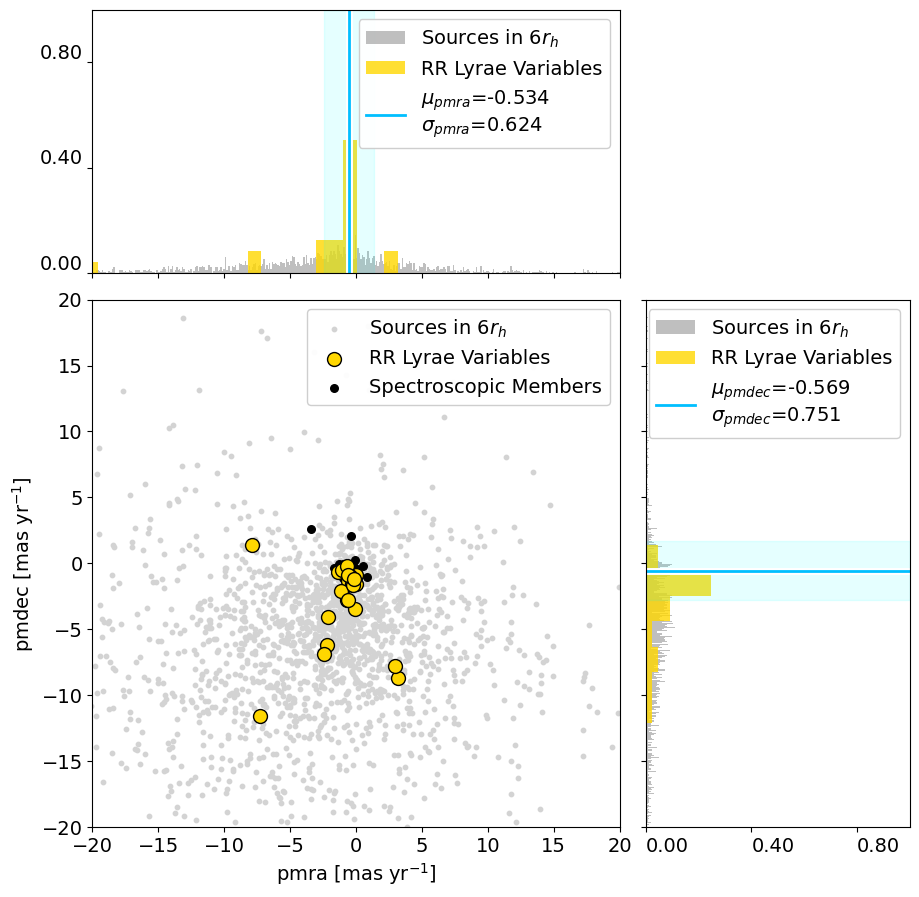

In [22]:
## PROPER MOTIONS

pm3 = plt.figure(layout='tight', figsize=(11,11))
ax3 = pm3.add_subplot()

ax3.set_aspect('equal')

ax3_histx = ax3.inset_axes([0, 1.05, 1, 0.5], sharex=ax3)
ax3_histy = ax3.inset_axes([1.05, 0, 0.5, 1], sharey=ax3)

scatter_hist(data_5rh['pmra'], data_5rh['pmdec'], rr['pmra'], rr['pmdec'], ax3, ax3_histx, ax3_histy, center_mymemb, err_mymemb)

ax3.scatter(memb['pmra'], memb['pmdec'], s=30, color='black', edgecolor='k', label='Spectroscopic Members')

ax3.legend(loc=1, fontsize=14, framealpha=0.95)

plt.setp(ax3_histy.get_xticklabels(), ha='left')
plt.setp(ax3_histx.get_yticklabels(), va='bottom')

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_pm_join.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Sources within 3$\sigma$ of mean proper motions (w.r.t. Spectroscopic Members)

In [23]:
## Sources in 3°

mask4 = (data['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_final = data[mask4]

mask4 = (data_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_final = data_final[mask4]

print('Sources within 3sigma of mean proper motions in 3°: ' + str(len(data_final)))


## Sources in 5*r_h

mask4 = (data_5rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_5rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_5rh_final = data_5rh[mask4]

mask4 = (data_5rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_5rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_5rh_final = data_5rh_final[mask4]

print('Sources within 3sigma of mean proper motions in 5r_h: ' + str(len(data_5rh_final)))


## RR Lyrae in 3°

mask5 = (rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_final = rr[mask5]

mask5 = (rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_final = rr_final[mask5]

print('RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(rr_final)))


## RR Lyrae in 5*r_h

mask6 = (rr_5rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr_5rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_5rh_final = rr_5rh[mask6]

mask6 = (rr_5rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_5rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_5rh_final = rr_5rh_final[mask6]

print('RR Lyrae within 3sigma of mean proper motions in 5r_h: ' + str(len(rr_5rh_final)))

Sources within 3sigma of mean proper motions in 3°: 6634
Sources within 3sigma of mean proper motions in 5r_h: 238
RR Lyrae within 3sigma of mean proper motions in 3°: 14
RR Lyrae within 3sigma of mean proper motions in 5r_h: 8


### Period-Wesenheit-Metallicity Relation

In [24]:
w_mag_final = wesen(rr_final['int_average_g'], rr_final['phot_bp_mean_mag'], rr_final['phot_rp_mean_mag'])
w_mag_error_final = wesen_err(rr_final['int_average_g_error'], rr_final['phot_bp_mean_mag_error'], rr_final['phot_rp_mean_mag_error'])
w_mag_tau = wesen(tau_rr['int_average_g'], tau_rr['phot_bp_mean_mag'], tau_rr['phot_rp_mean_mag'])
w_mag_memb_rr = wesen(memb_rr['int_average_g'], memb_rr['phot_bp_mean_mag'], memb_rr['phot_rp_mean_mag'])


## Garofalo et al. 2022: intrinsic dispersion of 0.09 ± 0.01 mag

w_sigma = 0.09


## Period

period_final = np.log10(rr_final['pf'])
period_final[np.isnan(period_final)] = np.log10(rr_final['p1_o'][np.isnan(period_final)]) + 0.127


## Info. from Vivas et al. 2020

# Distance Module

mu0 = float(- 5 + 5 * np.log10(vivas['distance'] * 1000.0))

print('Distance Module: ' + str(mu0))


# Iron Abundance

fe = float(vivas['fe_h'])

print('Iron Abundance: ' + str(fe))


## General Wesenheit Relation

pw_line_final = pw(period_final, fe, mu0)


# Generic only for plot

t = np.linspace(-0.5, 0, 100)
pw_generic = pw(t, fe, mu0)


## RR Lyrae in 3sigma of PW

rr_pw_final = rr_final.copy()
rr_pw_final.insert(len(rr_pw_final.columns), 'w_mag', w_mag_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'w_period', period_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'pw_line', pw_line_final)

mask_pw_final = ((w_mag_final <= pw_line_final + 3*w_sigma) & (w_mag_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final + w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final + w_mag_error_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final - w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final - w_mag_error_final >= pw_line_final - 3*w_sigma))

rr_pw_final = rr_pw_final[mask_pw_final]

print('RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(rr_pw_final)))

Distance Module: 19.933858671331226
Iron Abundance: -2.1
RR Lyrae within 3sigma of Wesenheit Relation: 7


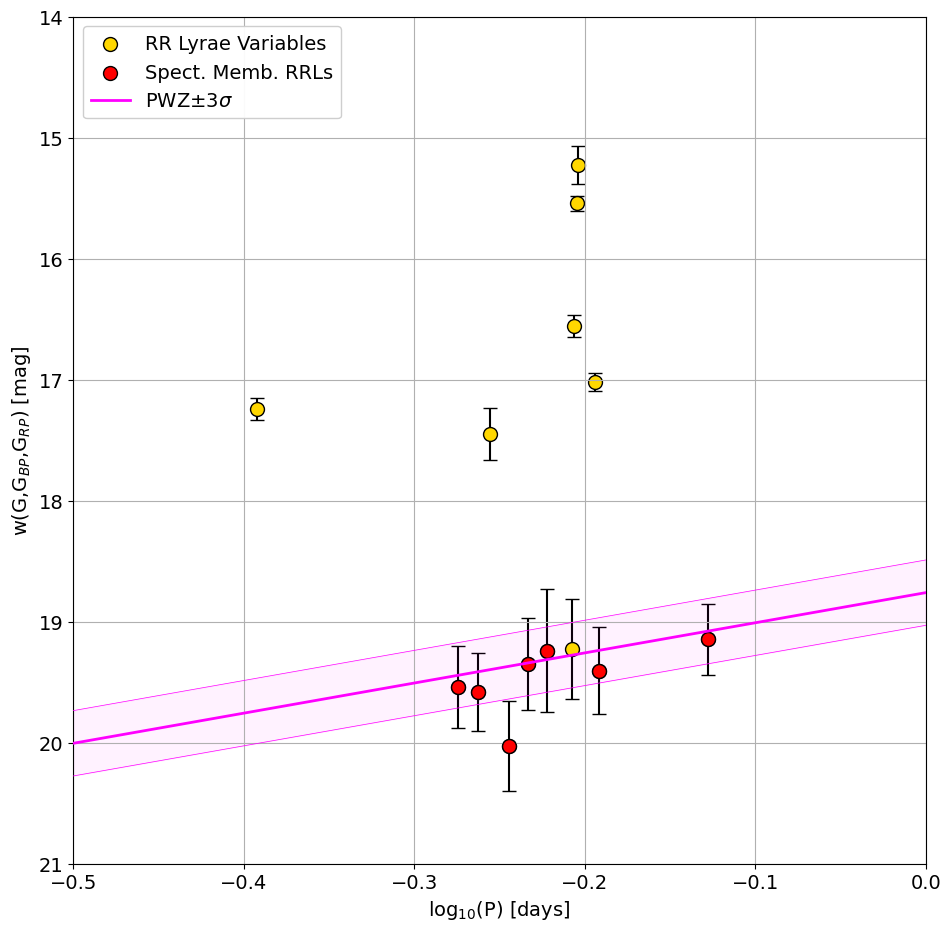

In [25]:
## PWZ

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0)
plt.ylim(21,14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'log$_{10}$(P) [days]', fontsize=14)
plt.ylabel(r'w(G,G$_{BP}$,G$_{RP}$) [mag]', fontsize=14)

plt.scatter(np.log10(rr_final['pf']), w_mag_final, c='gold', edgecolor='k', marker='o', s=100, label='RR Lyrae Variables', zorder=1)
plt.scatter(np.log10(rr_final['p1_o'])+0.127, w_mag_final, c='gold', edgecolor='k', marker='o', s=100, zorder=1) # FONDAMENTALIZZAZIONE
plt.errorbar(np.log10(rr_final['pf']), w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(rr_final['p1_o'])+0.127, w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(memb_rr['pf']), w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, label='Spect. Memb. RRLs', zorder=2)
plt.scatter(np.log10(memb_rr['p1_o'])+0.127, w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, zorder=2)

plt.plot(t, pw_generic, c='magenta', linewidth=2, label=r'PWZ$\pm 3 \sigma$', linestyle = 'solid', zorder=4)
plt.plot(t, pw_generic + 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid', zorder=4)
plt.plot(t, pw_generic - 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid', zorder=4)
plt.fill_between(t, pw_generic + 3*w_sigma, pw_generic - 3*w_sigma, alpha=0.05, color='magenta', zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/UrsaMajorI/UrsaMajorI_paper02.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


### Color-Magnitude Diagram

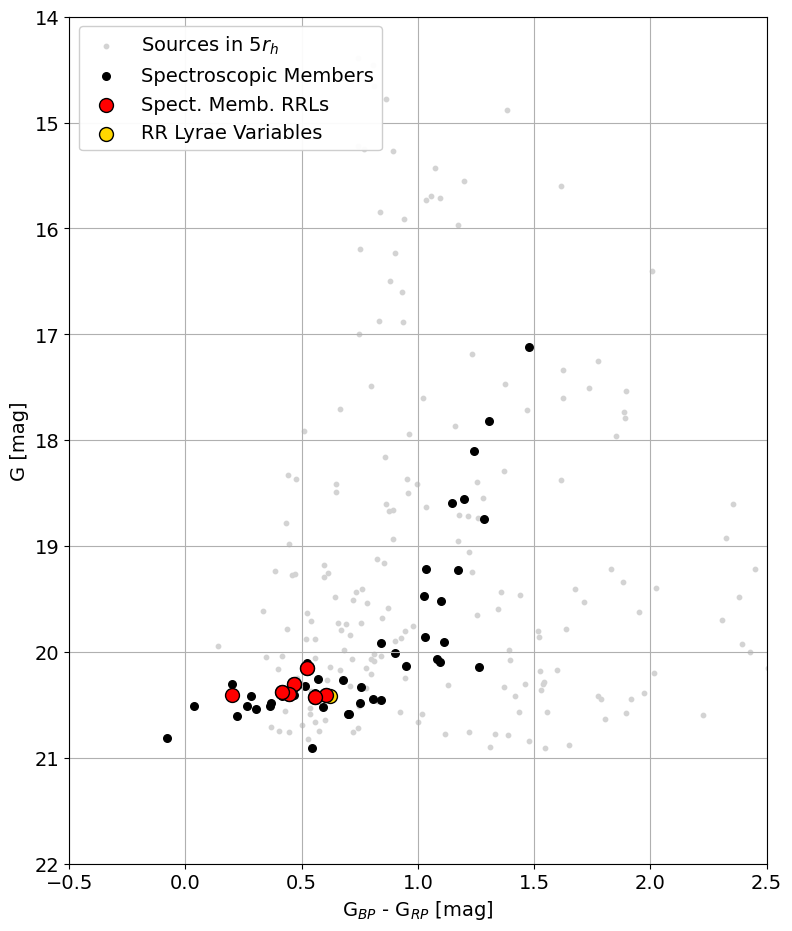

In [26]:
## CMD

plt.figure(figsize=(9,11))
plt.xlim(-0.5,2.5)
plt.ylim(22,14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(data_5rh_final['phot_bp_mean_mag'] - data_5rh_final['phot_rp_mean_mag'], data_5rh_final['phot_g_mean_mag'], s=10, c='lightgrey', marker='o', label=r'Sources in 5$r_h$', zorder=0)
plt.scatter(memb['phot_bp_mean_mag'] - memb['phot_rp_mean_mag'], memb['phot_g_mean_mag'], s=30, marker='o', c='k', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['phot_bp_mean_mag'] - memb_rr['phot_rp_mean_mag'], memb_rr['int_average_g'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['phot_bp_mean_mag'] - rr_pw_final['phot_rp_mean_mag'], rr_pw_final['int_average_g'], s=100, marker='o', edgecolor='k', color='gold', label=r'RR Lyrae Variables', zorder=2)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/UrsaMajorI/UrsaMajorI_paper03.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

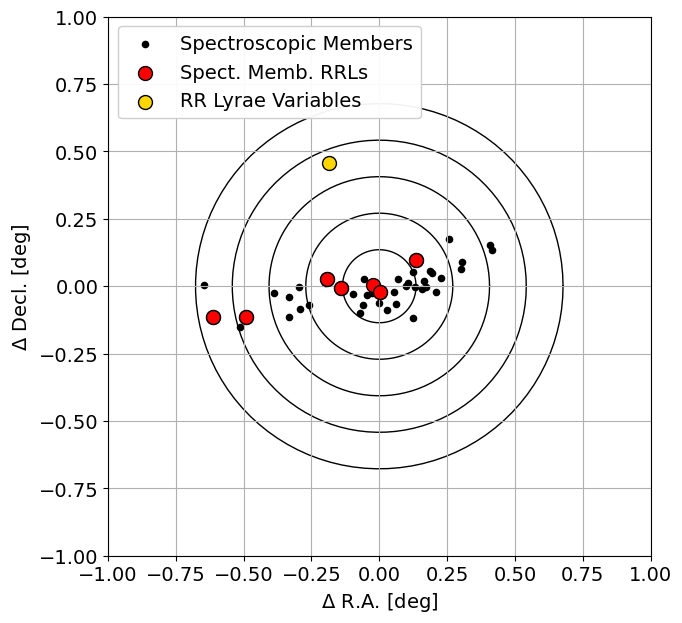

In [27]:
## Final map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(7,7))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=20, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['ra']- center[0], rr_pw_final['dec']- center[1], s=100, marker='o', c='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/UrsaMajorI/UrsaMajorI_final_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

## File saving

In [28]:
# RR Lyrae in 3° after PM cut
#rr_final.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_pm.csv', index=False)

# Final 7 RRL in Ursa Majot I
print('Final member RR Lyrae: ' + str(len(rr_pw_final)))
#rr_pw_final.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_pm+pwz.csv', index=False)


# Final 8 RRLs in Ursa Major I
#   (we added the Spectroscopic member which does not pass PWZ)
final = rr_pw_final.merge(memb_rr, how='outer')
print('Final member RR Lyrae + spectroscopic members: ' + str(len(final)))
final.to_csv('Output/UrsaMajorI/UrsaMajorI_rr_final.csv', index=False)

Final member RR Lyrae: 7
Final member RR Lyrae + spectroscopic members: 8


## Conclusions
- After Proper Motion and PWZ selections, we found 7 RRLs from vari_rrlyrae and we retrieved 1 spectroscopic member which did not pass PWZ
- 6 out of 7 Spectroscopic RRL members pass the PWZ selection
- There are no Sagittarius stream RRLs in this region of the sky